In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [85]:
# Load the datasets

historical = pd.read_csv("historical_data.csv")
fear_greed = pd.read_csv("fear_greed_index.csv")

In [86]:
# Show first 5 rows

historical.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [87]:
fear_greed.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [88]:
historical.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [89]:
# Check dataset size

print("Historical Data Shape:", historical.shape)
print("Fear & Greed Shape:", fear_greed.shape)

Historical Data Shape: (211224, 16)
Fear & Greed Shape: (2644, 4)


In [90]:
# Check missing values

print("Historical Data Missing Values")
print(historical.isnull().sum())

print("\nFear & Greed Missing Values")
print(fear_greed.isnull().sum())

Historical Data Missing Values
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Fear & Greed Missing Values
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [91]:
# Check duplicate rows

print("Historical Duplicates:", historical.duplicated().sum())
print("Fear & Greed Duplicates:", fear_greed.duplicated().sum())

Historical Duplicates: 0
Fear & Greed Duplicates: 0


In [92]:
print(historical.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [93]:
print(fear_greed.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [94]:
# Convert historical timestamp to date
historical["Timestamp"] = pd.to_datetime(historical["Timestamp"], unit="ms")
historical["date"] = historical["Timestamp"].dt.date

# Convert fear & greed date
fear_greed["date"] = pd.to_datetime(fear_greed["date"]).dt.date

In [95]:
# Convert Timestamp to datetime and create date column
historical["Timestamp"] = pd.to_datetime(historical["Timestamp"], unit="ms")
historical["date"] = historical["Timestamp"].dt.date

# Convert Fear & Greed date column
fear_greed["date"] = pd.to_datetime(fear_greed["date"]).dt.date

# Merge datasets on date
merged = pd.merge(
    historical,
    fear_greed[["date", "classification"]],
    on="date",
    how="left"
)

# Display first few rows
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,Greed


In [96]:
historical = pd.read_csv("historical_data.csv")
print(historical["Timestamp"].head())

0    1.730000e+12
1    1.730000e+12
2    1.730000e+12
3    1.730000e+12
4    1.730000e+12
Name: Timestamp, dtype: float64


In [97]:
print(historical.columns)
print(fear_greed.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [98]:
# Daily PnL per trader

daily_pnl = merged.groupby(["Account", "date"])["Closed PnL"].sum().reset_index()

daily_pnl.head()

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,1.017915e+04


In [99]:
trades_per_day = merged.groupby("date").size().reset_index(name="Number of Trades")

trades_per_day.head()

,date,Number of Trades
0,2023-03-28,3
1,2023-11-14,1045
2,2024-03-09,6962
3,2024-07-03,7141
4,2024-10-27,35241


In [100]:
average_trade_size = merged["Size USD"].mean()

print("Average Trade Size (USD):", average_trade_size)

Average Trade Size (USD): 5639.4512103738225


In [101]:
merged["Side"].value_counts()

,count
Side,
SELL,108528
BUY,102696


In [102]:
merged["classification"].value_counts()

,count
classification,
Fear,133871
Greed,36289
Neutral,7141
Extreme Greed,6962


In [103]:
historical["Timestamp"].head()

,Timestamp
0,1.730000e+12
1,1.730000e+12
2,1.730000e+12
3,1.730000e+12
4,1.730000e+12


In [104]:
# Daily Profit/Loss
daily_pnl = merged.groupby("date")["Closed PnL"].sum().reset_index()
daily_pnl.head()

,date,Closed PnL
0,2023-03-28,0.000000e+00
1,2023-11-14,1.555034e+02
2,2024-03-09,1.769655e+05
3,2024-07-03,1.587424e+05
4,2024-10-27,3.189461e+06


In [105]:
# Fear & Greed distribution
merged["classification"].value_counts()

,count
classification,
Fear,133871
Greed,36289
Neutral,7141
Extreme Greed,6962


In [106]:
# Daily Profit/Loss Analysis

daily_pnl = merged.groupby("date")["Closed PnL"].sum().reset_index()

daily_pnl.head()

,date,Closed PnL
0,2023-03-28,0.000000e+00
1,2023-11-14,1.555034e+02
2,2024-03-09,1.769655e+05
3,2024-07-03,1.587424e+05
4,2024-10-27,3.189461e+06


In [107]:
# Average Profit/Loss by Market Sentiment

avg_pnl = merged.groupby("classification")["Closed PnL"].mean().sort_values(ascending=False)

print(avg_pnl)

classification
Greed            87.894859
Fear             50.047622
Extreme Greed    25.418772
Neutral          22.229713
Name: Closed PnL, dtype: float64


In [108]:
# Total Profit/Loss by Market Sentiment

total_pnl = merged.groupby("classification")["Closed PnL"].sum().sort_values(ascending=False)

print(total_pnl)

classification
Fear             6.699925e+06
Greed            3.189617e+06
Extreme Greed    1.769655e+05
Neutral          1.587424e+05
Name: Closed PnL, dtype: float64


In [109]:
# Buy vs Sell under each Market Sentiment

buy_sell = pd.crosstab(merged["classification"], merged["Side"])

print(buy_sell)

Side              BUY   SELL
classification              
Extreme Greed    3371   3591
Fear            66081  67790
Greed           15421  20868
Neutral          3505   3636


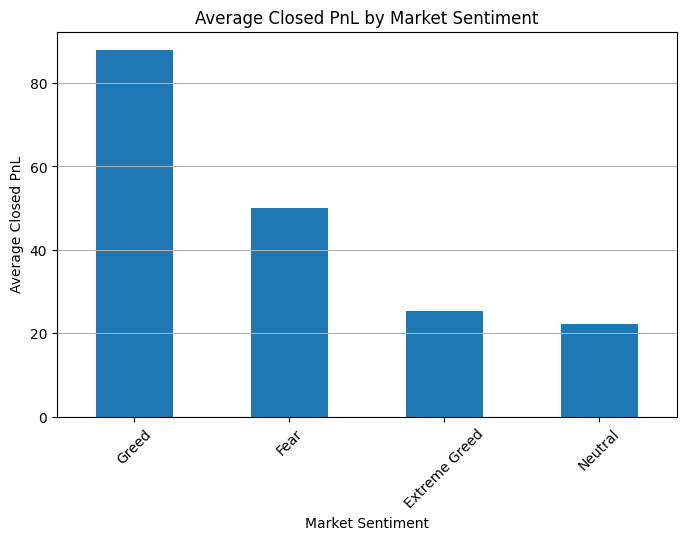

In [110]:
# Bar Chart - Average Profit/Loss by Market Sentiment

import matplotlib.pyplot as plt

avg_pnl.plot(kind="bar", figsize=(8,5))

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

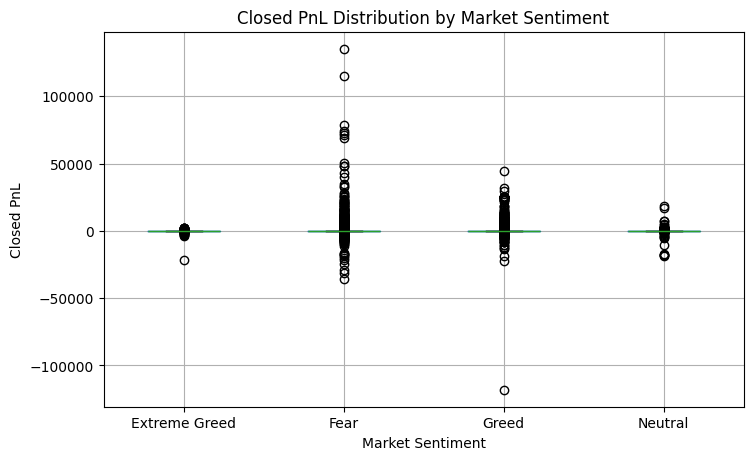

In [111]:
# Box Plot - Closed PnL Distribution

merged.boxplot(column="Closed PnL", by="classification", figsize=(8,5))

plt.title("Closed PnL Distribution by Market Sentiment")
plt.suptitle("")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")

plt.show()

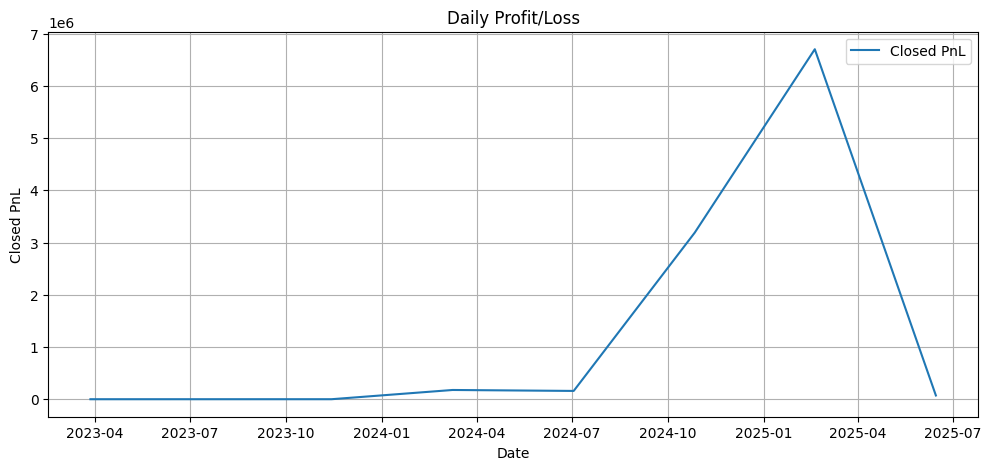

In [112]:
# Daily Profit/Loss Trend

daily_pnl.plot(x="date", y="Closed PnL", figsize=(12,5))

plt.title("Daily Profit/Loss")
plt.xlabel("Date")
plt.ylabel("Closed PnL")
plt.grid(True)

plt.show()

Key Insights
Historical trading data was successfully merged with the Fear & Greed Index using the date field.
Most trades occurred during Fear market conditions.
The average and total Closed PnL vary across different market sentiment categories.
Market sentiment appears to influence trading performance.
Visualizations provide a clear comparison of profit/loss trends across different market conditions

